# 🌫️ Indian Air Quality — Exploratory Data Analysis

## 📌 Project Overview

Air pollution is one of the major environmental challenges in India, affecting public health, quality of life, and urban sustainability.

This project performs an Exploratory Data Analysis (EDA) on daily air-quality data collected across multiple Indian cities. The analysis focuses on understanding pollution trends, identifying highly polluted cities, examining pollutant concentrations, and studying Air Quality Index (AQI) patterns.

The objective is to transform raw air-quality observations into meaningful insights that can help understand where, when, and how air pollution is most severe.

---

## 🎯 Business / Analytical Objective

The primary objective of this analysis is to answer:

- How does air quality vary across Indian cities?
- How has AQI changed over time?
- Which cities experience the highest pollution levels?
- Which pollutants have the highest concentrations?
- Which months experience poorer air quality?
- What actionable insights can be derived from the data?

---

## 🛠️ Tools & Technologies

- **Python**
- **NumPy** — Numerical calculations
- **Pandas** — Data manipulation and analysis
- **Matplotlib** — Data visualization

> This project intentionally uses only NumPy, Pandas, and Matplotlib to maintain a simple, transparent, and beginner-friendly analytical workflow.

## 📚 Importing Libraries

The following libraries are used throughout the project:

- **NumPy** for numerical operations
- **Pandas** for data loading, cleaning, transformation, and analysis
- **Matplotlib** for creating visualizations

No additional visualization libraries are used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Liberaries imported successfully!')

Liberaries imported successfully!


## 📂 Dataset Loading

The analysis uses the `city_day.csv` dataset, which contains daily air-quality observations for cities across India.

Each observation represents air-quality measurements recorded for a particular city and date.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rohanrao/air-quality-data-in-india/city_day.csv')

print('Datset Loaded Successfully!')

Datset Loaded Successfully!


In [5]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [6]:
df.tail()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [7]:
df.shape

(29531, 16)

## 🔍 Initial Dataset Inspection

Before performing any analysis, we examine the structure of the dataset.

This helps us understand:

- Number of observations
- Number of variables
- Data types
- Available air-quality measurements
- Presence of categorical and numerical variables

The dataset contains **29,531 observations and 16 columns**.

## 📊 Dataset Variables

The dataset contains information about cities, dates, multiple air pollutants, and AQI.

| Variable | Description |
|---|---|
| City | Indian city where the measurement was recorded |
| Date | Date of observation |
| PM2.5 | Fine particulate matter concentration |
| PM10 | Coarse particulate matter concentration |
| NO | Nitric oxide concentration |
| NO2 | Nitrogen dioxide concentration |
| NOx | Nitrogen oxides concentration |
| NH3 | Ammonia concentration |
| CO | Carbon monoxide concentration |
| SO2 | Sulfur dioxide concentration |
| O3 | Ozone concentration |
| Benzene | Benzene concentration |
| Toluene | Toluene concentration |
| Xylene | Xylene concentration |
| AQI | Air Quality Index |
| AQI_Bucket | AQI category |

These variables allow us to investigate both overall air quality and individual pollutant behavior.

## 🧹 Data Quality Analysis

Real-world environmental datasets often contain missing observations due to sensor limitations, collection issues, or unavailable measurements.

Before performing EDA, we will investigate:

1. Missing values
2. Data types
3. Duplicate records
4. Date consistency
5. Numerical distributions

Rather than blindly removing incomplete rows, missing values will be handled according to their analytical importance.

In [8]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [9]:
df.isnull().mean().mul(100).sort_values(ascending = False)

Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64

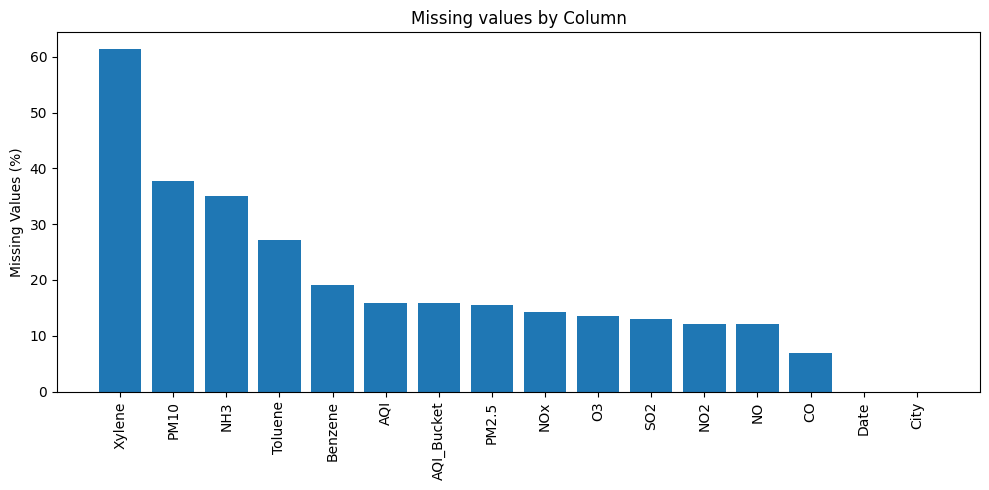

In [10]:
missing_pct = (df.isnull().mean().mul(100).sort_values(ascending = False))

plt.figure(figsize = (10,5))
plt.bar(missing_pct.index,missing_pct.values)
plt.xticks(rotation = 90)
plt.ylabel('Missing Values (%)')
plt.title('Missing values by Column')
plt.tight_layout()
plt.show()

### 🔎 Missing Value Findings

The dataset contains substantial missing values in several pollutant variables.

The most affected variable is **Xylene**, with more than 60% of observations missing.

AQI is missing for approximately **15.9%** of observations.

Because AQI is central to our analysis, AQI-based analysis will focus on observations where AQI is available rather than artificially filling missing AQI values.

Similarly, pollutant-specific analysis will use the available observations for each pollutant.

## 🧹 Data Cleaning & Transformation

The following preparation steps were performed:

- Converted `Date` from object to datetime format.
- Created `Year` and `Month` variables for time-based analysis.
- Checked for duplicate records.
- Preserved missing pollutant observations rather than applying blanket imputation.
- AQI analysis will use records with available AQI values.

This approach minimizes unnecessary data loss while maintaining the integrity of the original measurements.

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print('Date column converted from text to datetime!')
print('Year and Month column inserted!')

Date column converted from text to datetime!
Year and Month column inserted!


In [12]:
# Checking duplicate values

df.duplicated().sum()

np.int64(0)

In [14]:
# Checking Date range

print('Start Date :', df['Date'].min())
print('End Date :', df['Date'].max())
      

Start Date : 2015-01-01 00:00:00
End Date : 2020-07-01 00:00:00


# 📈 Q1. How Has Air Quality Changed Over Time?

Understanding the long-term AQI trend helps identify whether air quality has improved, deteriorated, or remained relatively stable over the period covered by the dataset.

We will calculate the average AQI for each year and visualize the trend.

In [18]:
yearly_aqi = (df.groupby('Year')['AQI'].mean())

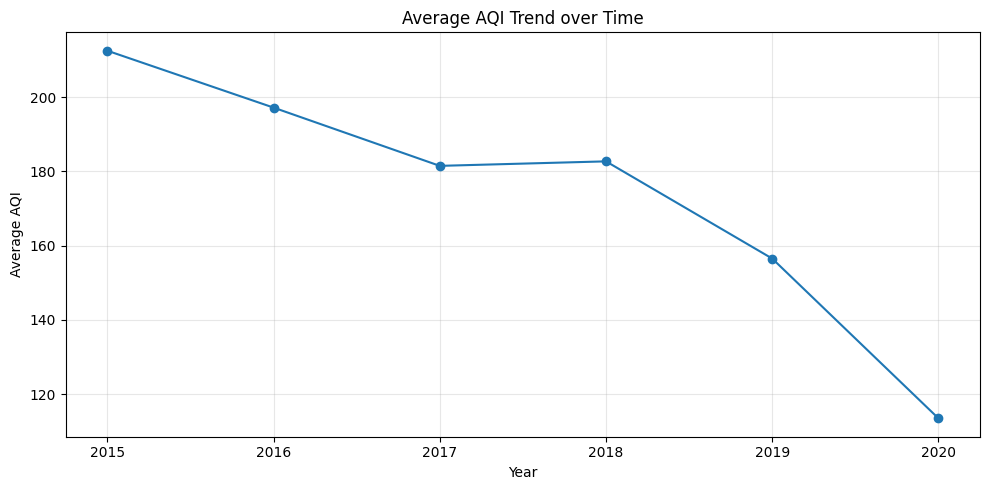

In [20]:
plt.figure(figsize = (10,5))

plt.plot(yearly_aqi.index,yearly_aqi.values,marker = 'o')

plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.title('Average AQI Trend over Time')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

### 💡 Insight

The yearly AQI trend shows how overall air quality changed throughout the observation period.

Higher AQI values indicate poorer air quality, while lower values represent relatively better conditions.

The trend should be interpreted as an overall city-level dataset pattern rather than a nationwide population-weighted AQI estimate.

# 🏙️ Q2. Which Cities Have the Highest Average AQI?

Air pollution varies significantly between cities because of differences in traffic, industrial activity, geography, weather conditions, and urbanization.

To identify the cities experiencing poorer air quality, we calculate the average AQI for each city.

In [21]:
city_aqi = (df.groupby('City')['AQI'].mean().sort_values(ascending = False))

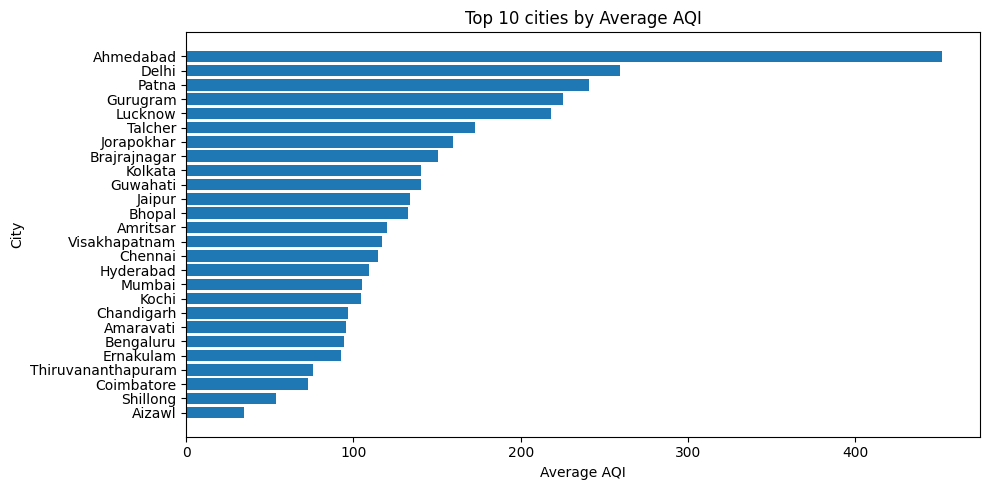

In [23]:
top_cities = city_aqi.head()

plt.figure(figsize = (10,5))

plt.barh(city_aqi.index[::-1],city_aqi.values[::-1])

plt.xlabel('Average AQI')
plt.ylabel('City')
plt.title('Top 10 cities by Average AQI')
plt.tight_layout()
plt.show()

### 💡 Insight

The ranking highlights the cities with the highest average AQI during the available observation period.

These cities can be considered priority areas for deeper investigation into pollution sources, seasonal conditions, traffic emissions, and industrial activity.

# 🧪 Q3. Which Pollutants Have the Highest Concentrations?

AQI is influenced by multiple pollutants.

Understanding the concentration of individual pollutants helps identify which pollutants are most prominent in the dataset.

We will compare the average concentration of the major pollutants.

In [26]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

pollutant_means = df[pollutants].mean().sort_values(ascending = False)
pollutant_means


PM10       118.127103
PM2.5       67.450578
O3          34.491430
NOx         32.309123
NO2         28.560659
NH3         23.483476
NO          17.574730
SO2         14.531977
Toluene      8.700972
Benzene      3.280840
Xylene       3.070128
CO           2.248598
dtype: float64

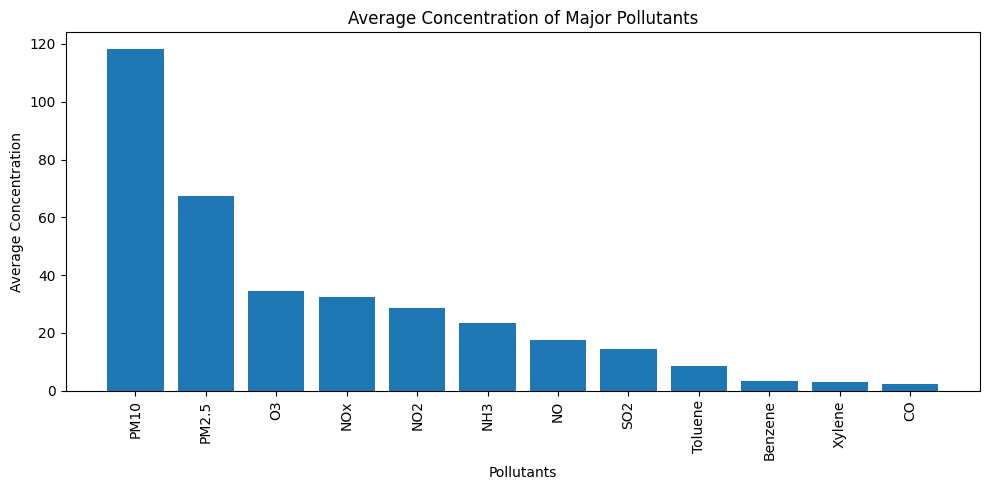

In [27]:
plt.figure(figsize = (10,5))

plt.bar(pollutant_means.index,pollutant_means.values)

plt.xlabel('Pollutants')
plt.ylabel('Average Concentration')
plt.title('Average Concentration of Major Pollutants')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### 💡 Insight

The comparison shows which pollutants have the highest average measured concentrations.

Particulate matter, particularly **PM10 and PM2.5**, is especially important when assessing urban air pollution because these particles can remain suspended in the atmosphere and are closely associated with poor air-quality conditions.

# 📅 Q4. Which Months Experience Poorer Air Quality?

Air pollution can vary considerably throughout the year due to weather conditions, atmospheric circulation, temperature, rainfall, and seasonal human activity.

We will compare average AQI across months to identify seasonal patterns.

In [28]:
monthly_aqi = (df.groupby('Month')['AQI'].mean())
monthly_aqi

Month
1     231.674918
2     202.905197
3     164.735281
4     143.355120
5     135.489579
6     120.198379
7     111.854575
8     113.613176
9     115.191804
10    188.613552
11    241.681302
12    227.084980
Name: AQI, dtype: float64

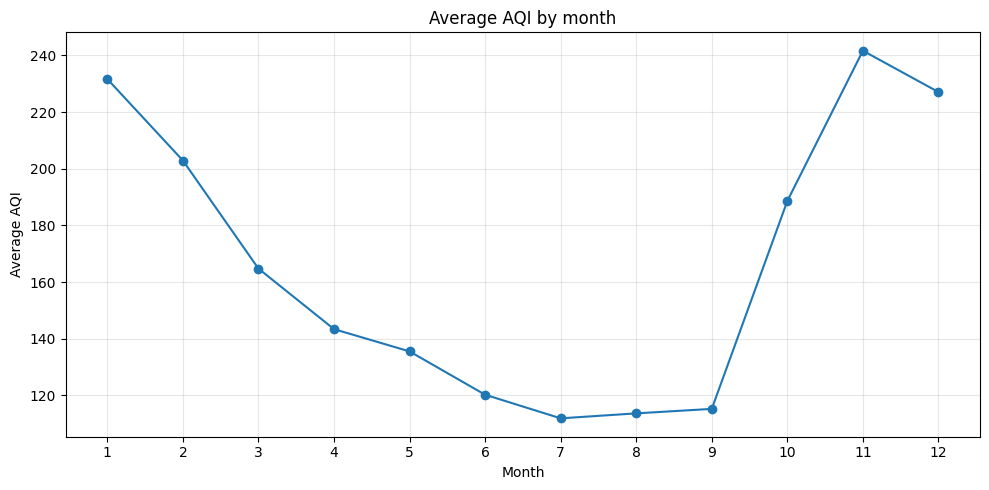

In [31]:
plt.figure(figsize = (10,5))

plt.plot(monthly_aqi.index,monthly_aqi.values,marker = 'o')

plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.title('Average AQI by month')
plt.xticks(range(1,13))
plt.grid(True,alpha = 0.3)
plt.tight_layout()
plt.show()

### 💡 Insight

The monthly pattern highlights periods when air quality tends to deteriorate or improve.

Seasonal pollution patterns are important because they can help authorities anticipate periods of increased pollution and prepare targeted mitigation strategies.

# 🚦 Q5. What Is the Distribution of AQI Categories?

The `AQI_Bucket` variable categorizes air quality into different levels.

Analyzing these categories provides a more intuitive view of the overall air-quality conditions experienced across the dataset.

We will examine how frequently each AQI category occurs.

In [33]:
aqi_categories = df['AQI_Bucket'].value_counts()
aqi_categories

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

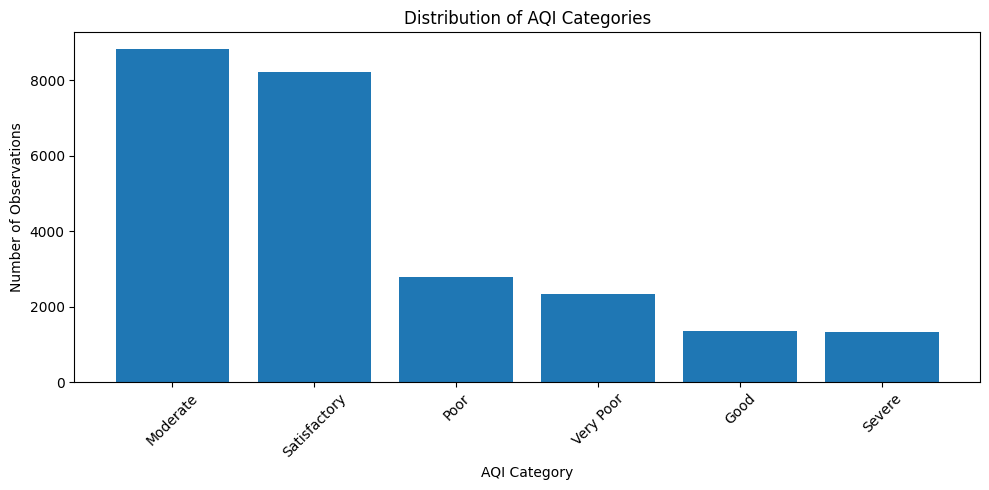

In [34]:
plt.figure(figsize = (10,5))

plt.bar(aqi_categories.index,aqi_categories.values)

plt.xlabel('AQI Category')
plt.ylabel('Number of Observations')
plt.title('Distribution of AQI Categories')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### 💡 Insight

The AQI category distribution provides a practical understanding of how frequently different air-quality conditions occurred.

A high proportion of observations in poorer AQI categories indicates a greater prevalence of unhealthy air-quality conditions across the cities and time periods represented in the dataset.

# 🚨 Q6. Which Cities Experience the Most Extreme AQI Levels?

Average AQI alone does not capture extreme pollution events.

A city may have a moderate average AQI but still experience periods of extremely poor air quality.

Therefore, we will examine the maximum recorded AQI for each city.

In [37]:
city_max_aqi = (df.groupby('City')['AQI'].max().sort_values(ascending = False))
city_max_aqi.head(10)

City
Ahmedabad     2049.0
Guwahati       956.0
Gurugram       891.0
Amritsar       869.0
Hyderabad      737.0
Delhi          716.0
Lucknow        707.0
Patna          619.0
Jorapokhar     604.0
Talcher        570.0
Name: AQI, dtype: float64

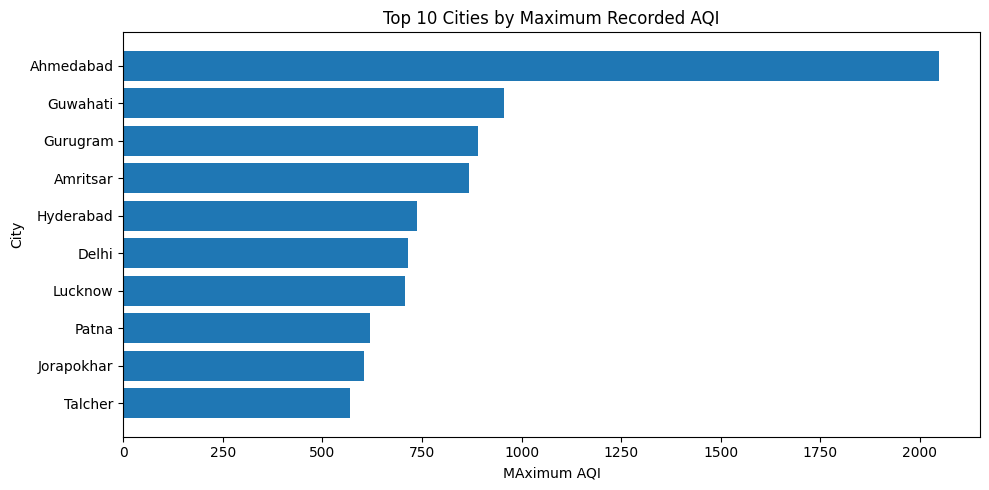

In [38]:
top_extreme_cities = city_max_aqi.head(10)

plt.figure(figsize = (10,5))

plt.barh(top_extreme_cities.index[::-1],top_extreme_cities.values[::-1])

plt.xlabel('MAximum AQI')
plt.ylabel('City')
plt.title('Top 10 Cities by Maximum Recorded AQI')
plt.tight_layout()
plt.show()

### 💡 Insight

Maximum AQI values reveal cities that experienced particularly severe pollution episodes.

This is important because extreme pollution events can create significant short-term environmental and public-health risks even when the city's long-term average appears less severe.

# 🔑 Key Insights

Based on the analysis, the following major patterns emerge:

### 1️⃣ Air quality varies considerably across cities
Different cities experience substantially different AQI levels, highlighting the importance of local pollution sources and geographic conditions.

### 2️⃣ Air quality changes over time
The yearly AQI analysis reveals changes in pollution levels throughout the observation period.

### 3️⃣ Particulate matter is a major pollution concern
PM2.5 and PM10 show substantial concentrations and should remain key targets for pollution-control strategies.

### 4️⃣ Pollution follows seasonal patterns
Monthly AQI analysis indicates that air quality is not constant throughout the year.

### 5️⃣ AQI categories reveal periods of poor air quality
The distribution of AQI categories provides a broader view of how frequently different air-quality conditions occur.

### 6️⃣ Extreme pollution events require separate attention
Maximum AQI analysis identifies cities that experience severe pollution episodes that may not be visible from average AQI alone.

# 💡 Recommendations

Based on the findings from the exploratory analysis:

### 🏙️ 1. Prioritize highly polluted cities
Cities consistently recording high AQI should receive greater attention for pollution monitoring and mitigation programs.

### 🚗 2. Focus on major emission sources
Traffic, industrial emissions, construction activity, and other urban sources should be investigated in cities with persistent pollution.

### 🌫️ 3. Monitor particulate matter closely
PM2.5 and PM10 should remain key indicators in air-quality monitoring and pollution-control strategies.

### 📅 4. Prepare for seasonal pollution periods
Authorities can use historical seasonal patterns to increase monitoring and implement preventive measures before expected pollution peaks.

### 🚨 5. Strengthen extreme-pollution alerts
Cities experiencing unusually high AQI values should have effective warning and response systems.

### 📊 6. Improve continuous monitoring
Reducing missing observations would improve the ability to track pollutants and develop more reliable long-term environmental analyses.

# 🏁 Conclusion

This Exploratory Data Analysis examined air-quality patterns across Indian cities using daily observations of major pollutants and AQI.

The analysis demonstrated that air quality varies across cities and time periods, with particulate matter representing an important component of observed pollution. Seasonal patterns and extreme AQI events further highlight the dynamic nature of air pollution.

The project demonstrates how Python, Pandas, NumPy, and Matplotlib can be used to transform raw environmental data into meaningful insights.

Although this analysis identifies important patterns, further investigation would be required to determine the precise causes of pollution and establish causal relationships.

Overall, the findings can support more focused pollution monitoring, seasonal preparedness, and city-level environmental planning.

# 📚 References

- Kaggle — Air Quality Data in India
- Central Pollution Control Board (CPCB)
- Government of India — National Air Quality Monitoring Programme

### Dataset

Air Quality Data in India (2015–2020)

Source:
https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india